In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import time
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

# Configurações Globais
RANDOM_STATE = 42
NPZ_PATH = '/content/drive/MyDrive/2026/ic/npz_files/opportunity_v2.npz'

# ==========================================
# 1. CARREGAMENTO E DIVISÃO (DIRETO DO .NPZ)
# ==========================================

def load_data_and_split(path):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val = data['X_val']
        y_val = data['y_val']
        X_test = data['X_test']
        y_test = data['y_test']
    except FileNotFoundError:
        print(" Erro: Arquivo não encontrado.")
        return None

    print(f"   Treino Oficial: {X_train.shape}")
    print(f"   Validação Oficial: {X_val.shape}")
    print(f"   Teste Oficial: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [4]:
# ==========================================
# 2. PREPARAÇÃO DOS DADOS (CENÁRIOS)
# ==========================================

def prep_raw_data(X):
    """Cenário A: Dados Brutos (Flattening) - Sem normalização para RF"""
    return X.reshape(X.shape[0], -1)

def prep_features_data(X):
    """Cenário B: Feature Engineering (Stats) - Sem normalização para RF"""
    mean = np.mean(X, axis=1)
    std = np.std(X, axis=1)
    max_val = np.max(X, axis=1)
    min_val = np.min(X, axis=1)
    return np.hstack([mean, std, max_val, min_val])

In [5]:
# ==========================================
# 3. OTIMIZAÇÃO (OPTUNA)
# ==========================================
from optuna.samplers import TPESampler

def run_optuna_study(X_tr, y_tr, X_val, y_val, study_name):
    """
    Otimiza Pesos + Hiperparâmetros usando o conjunto de validação fixo.
    """
    def objective(trial):
        # 1. Hiperparâmetros da Floresta (Reduzido para agilizar)
        n_estimators = trial.suggest_int('n_estimators', 50, 300)

        max_depth_is_none = trial.suggest_categorical('max_depth_is_none', [True, False])
        max_depth = None if max_depth_is_none else trial.suggest_int('max_depth', 10, 50)

        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

        # 2. Estratégia de Pesos
        class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])

        # 3. Modelo
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_features=max_features,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1 # Usa todos os cores
        )

        # 4. Treino e Validação
        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        return f1_score(y_val, y_pred_val, average='macro')

    def print_status(study, trial):
        print(f"   Trial {trial.number + 1}/25 finalizado - F1: {trial.value:.4f} (Melhor até agora: {study.best_value:.4f})")

    print(f"\n--- Iniciando Optuna: {study_name} ---")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    sampler = TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)

    # Reduzido para 25 trials (busca mais rápida e eficiente)
    study.optimize(objective, n_trials=25, timeout=7200, callbacks=[print_status])

    print(f"   Melhor F1 Validação: {study.best_value:.4f}")
    print(f"   Melhores Params: {study.best_params}")
    return study.best_params


In [6]:
# ==========================================
# 4. TREINO FINAL E AVALIAÇÃO
# ==========================================
import time

def train_and_test(X_train_full, y_train_full, X_test, y_test, params, scenario_name):
    print(f" Treinando modelo final: {scenario_name}...")
    start_time = time.time()

    # 1. Configuração do Modelo
    if params == 'balanced':
        model = RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:
        # Passa os hiperparâmetros diretamente do Optuna
        p = params.copy()
        # Trata o hiperparâmetro auxiliar do Optuna para max_depth
        if p.pop('max_depth_is_none', False):
            p['max_depth'] = None

        model = RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **p
        )

    # 2. Treino
    model.fit(X_train_full, y_train_full)

    # 3. Predição
    y_pred = model.predict(X_test)
    duration = time.time() - start_time

    # 4. Cálculo de Métricas via Bootstrap
    print(f"   [Boot] Calculando Intervalo de Confiança para F1 e Acurácia...")
    boot_stats = run_bootstrap_validation(y_test, y_pred, n_iterations=1000)

    print(f"   Bootstrap F1: {boot_stats['Boot_F1_Mean']:.4f} | Acc: {boot_stats['Boot_Acc_Mean']:.4f} | Tempo: {duration:.2f}s")

    return {
        'Cenário': scenario_name,
        'F1_Mean': boot_stats['Boot_F1_Mean'],
        'F1_CI_Lower': boot_stats['Boot_F1_CI_Lower'],
        'F1_CI_Upper': boot_stats['Boot_F1_CI_Upper'],
        'Acc_Mean': boot_stats['Boot_Acc_Mean'],
        'Acc_CI_Lower': boot_stats['Boot_Acc_CI_Lower'],
        'Acc_CI_Upper': boot_stats['Boot_Acc_CI_Upper'],
        'Tempo (s)': duration,
        'y_test': y_test, # Guardamos para a matriz de confusão
        'y_pred': y_pred
    }


In [7]:
from sklearn.utils import resample
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# Reduzido n_iterations de 1000 para 500 para agilizar sem perder segurança estatística
def run_bootstrap_validation(y_true, y_pred, n_iterations=500):
    f1_stats = []
    acc_stats = []
    for _ in range(n_iterations):
        # Reamostragem com reposição
        y_true_res, y_pred_res = resample(y_true, y_pred, random_state=None)
        f1_stats.append(f1_score(y_true_res, y_pred_res, average='macro'))
        acc_stats.append(accuracy_score(y_true_res, y_pred_res))

    return {
        'Boot_F1_Mean': np.mean(f1_stats),
        'Boot_F1_CI_Lower': np.percentile(f1_stats, 2.5),
        'Boot_F1_CI_Upper': np.percentile(f1_stats, 97.5),
        'Boot_Acc_Mean': np.mean(acc_stats),
        'Boot_Acc_CI_Lower': np.percentile(acc_stats, 2.5),
        'Boot_Acc_CI_Upper': np.percentile(acc_stats, 97.5)
    }


In [8]:
# ==========================================
# 5. EXECUÇÃO PRINCIPAL
# ==========================================

# A. Carregar
(X_tr, y_tr), (X_val, y_val), (X_te, y_te) = load_data_and_split(NPZ_PATH)

results = []

# --- PARTE A: DADOS BRUTOS ---
print("\n=== PREPARANDO DADOS BRUTOS ===")
X_tr_raw = prep_raw_data(X_tr)
X_val_raw = prep_raw_data(X_val)
X_te_raw = prep_raw_data(X_te)

# 1. Raw + Baseline
results.append(train_and_test(
    X_tr_raw, y_tr, X_te_raw, y_te,
    'balanced', "1. Raw + Balanced"
))

# 2. Raw + Otimizado (Usando validação do NPZ)
best_params_raw = run_optuna_study(X_tr_raw, y_tr, X_val_raw, y_val, "Raw Data")
results.append(train_and_test(
    X_tr_raw, y_tr, X_te_raw, y_te,
    best_params_raw, "2. Raw + Otimizado"
))

# --- PARTE B: FEATURE ENGINEERING ---
print("\n===  PREPARANDO FEATURE ENGINEERING ===")
X_tr_feat = prep_features_data(X_tr)
X_val_feat = prep_features_data(X_val)
X_te_feat = prep_features_data(X_te)

# 3. Features + Baseline
results.append(train_and_test(
    X_tr_feat, y_tr, X_te_feat, y_te,
    'balanced', "3. Features + Balanced"
))

# 4. Features + Otimizado
best_params_feat = run_optuna_study(X_tr_feat, y_tr, X_val_feat, y_val, "Features")
results.append(train_and_test(
    X_tr_feat, y_tr, X_te_feat, y_te,
    best_params_feat, "4. Features + Otimizado"
))


 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/opportunity_v2.npz...
   Treino Oficial: (12411, 75, 242)
   Validação Oficial: (5852, 75, 242)
   Teste Oficial: (5198, 75, 242)

=== PREPARANDO DADOS BRUTOS ===
 Treinando modelo final: 1. Raw + Balanced...
   [Boot] Calculando Intervalo de Confiança para F1 e Acurácia...
   Bootstrap F1: 0.2064 | Acc: 0.7589 | Tempo: 147.08s

--- Iniciando Optuna: Raw Data ---
   Trial 1/25 finalizado - F1: 0.1276 (Melhor até agora: 0.1276)
   Trial 2/25 finalizado - F1: 0.0496 (Melhor até agora: 0.1276)
   Trial 3/25 finalizado - F1: 0.4253 (Melhor até agora: 0.4253)
   Trial 4/25 finalizado - F1: 0.3117 (Melhor até agora: 0.4253)
   Trial 5/25 finalizado - F1: 0.3407 (Melhor até agora: 0.4253)
   Trial 6/25 finalizado - F1: 0.2712 (Melhor até agora: 0.4253)
   Trial 7/25 finalizado - F1: 0.1109 (Melhor até agora: 0.4253)
   Trial 8/25 finalizado - F1: 0.3703 (Melhor até agora: 0.4253)
   Trial 9/25 finalizado - F1: 0.3795 (Melhor até ag


=== RESULTADOS FINAIS (MÉDIAS BOOTSTRAP) ===


,Cenário,F1_Mean,F1_CI_Lower,F1_CI_Upper,Acc_Mean,Acc_CI_Lower,Acc_CI_Upper,Tempo (s)
0,1. Raw + Balanced,0.206384,0.189300,0.224967,0.758935,0.747013,0.770301,147.078646
1,2. Raw + Otimizado,0.477382,0.452021,0.500523,0.778698,0.767603,0.790112,40.156040
2,3. Features + Balanced,0.283015,0.258914,0.306869,0.762741,0.752020,0.775106,48.381304
3,4. Features + Otimizado,0.675005,0.653301,0.697934,0.838536,0.827626,0.848403,60.479140


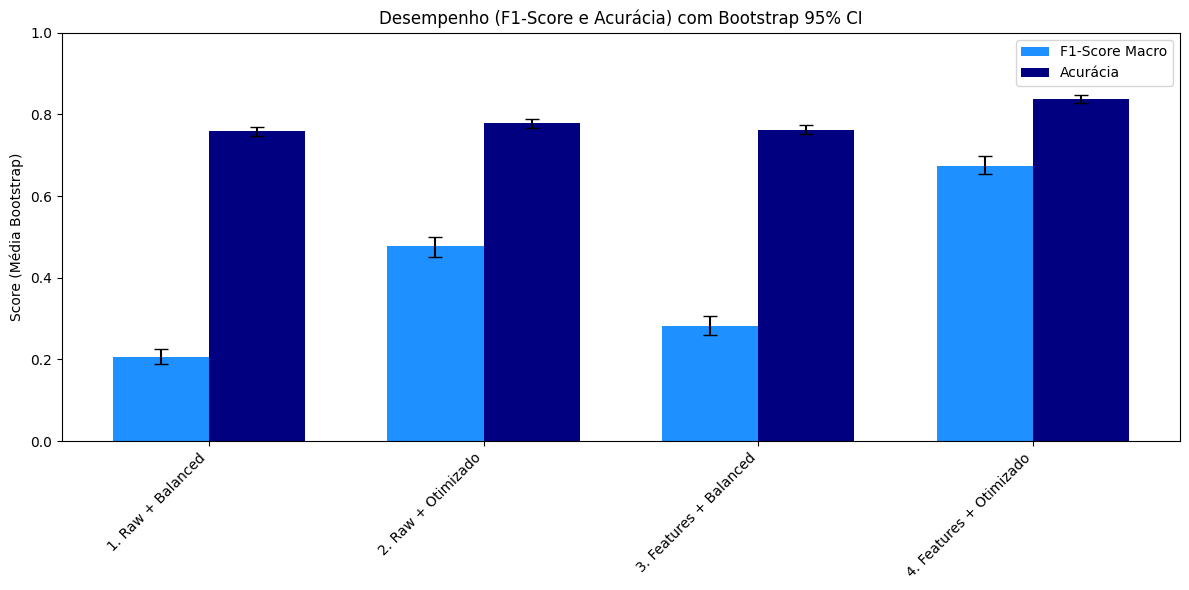


=== MATRIZES DE CONFUSÃO ===


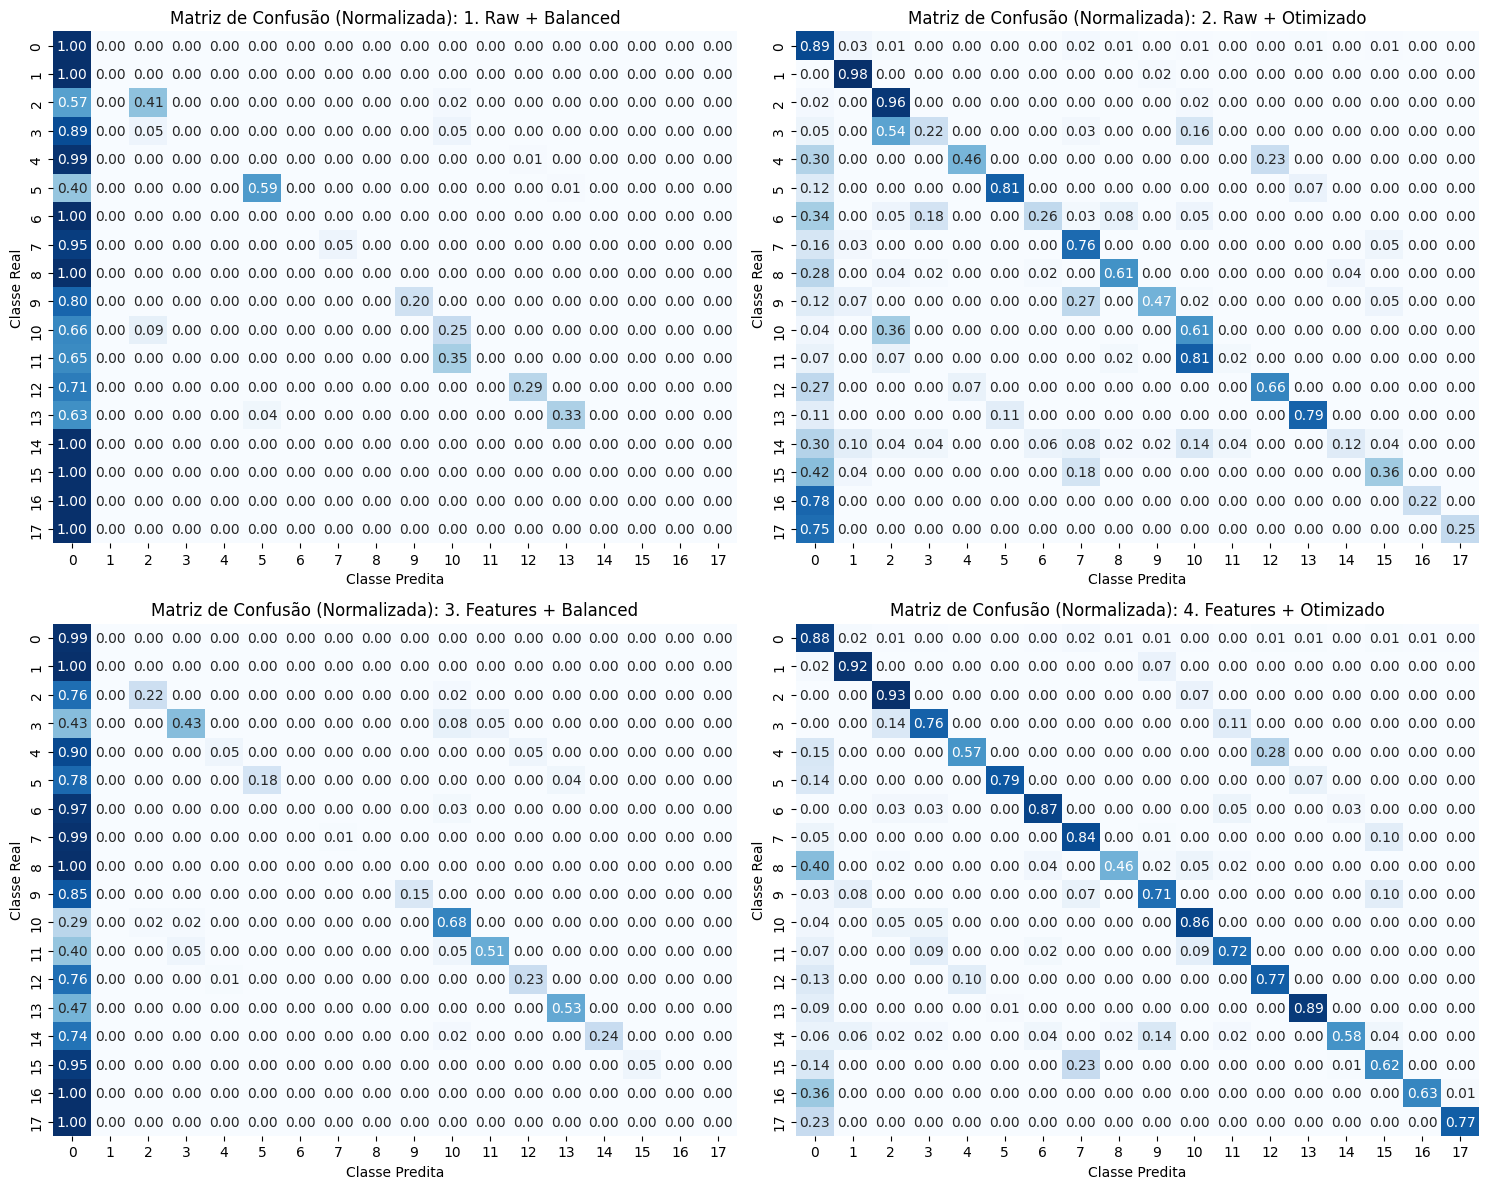

In [9]:
# ==========================================
# 6. RELATÓRIO E GRÁFICO
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# Preparar os dados para a tabela (removendo arrays grandes)
table_data = []
for r in results:
    row = r.copy()
    row.pop('y_test', None)
    row.pop('y_pred', None)
    table_data.append(row)

df_final = pd.DataFrame(table_data)
print("\n=== RESULTADOS FINAIS (MÉDIAS BOOTSTRAP) ===")
display(df_final)

# --- GRÁFICO DE BARRAS (F1 e Acurácia) ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_final['Cenário']))
width = 0.35

# Erros para o gráfico (distância da média até os limites do CI)
f1_yerr = [
    df_final['F1_Mean'] - df_final['F1_CI_Lower'],
    df_final['F1_CI_Upper'] - df_final['F1_Mean']
]
acc_yerr = [
    df_final['Acc_Mean'] - df_final['Acc_CI_Lower'],
    df_final['Acc_CI_Upper'] - df_final['Acc_Mean']
]

# Barras azuis
rects1 = ax.bar(x - width/2, df_final['F1_Mean'], width, yerr=f1_yerr, label='F1-Score Macro', color='dodgerblue', capsize=5)
rects2 = ax.bar(x + width/2, df_final['Acc_Mean'], width, yerr=acc_yerr, label='Acurácia', color='navy', capsize=5)

ax.set_ylabel('Score (Média Bootstrap)')
ax.set_title('Desempenho (F1-Score e Acurácia) com Bootstrap 95% CI')
ax.set_xticks(x)
ax.set_xticklabels(df_final['Cenário'], rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()

plt.tight_layout()
plt.show()

# --- MATRIZES DE CONFUSÃO ---
print("\n=== MATRIZES DE CONFUSÃO ===")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, r in enumerate(results):
    cm = confusion_matrix(r['y_test'], r['y_pred'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"Matriz de Confusão (Normalizada): {r['Cenário']}")
    axes[idx].set_xlabel("Classe Predita")
    axes[idx].set_ylabel("Classe Real")

plt.tight_layout()
plt.show()
